# 05 — Simulation: transportability, contextual leakage and decision quality
Runs the simulation study and exports manuscript tables and figures.

In [1]:
# !pip -q install pandas numpy matplotlib scikit-learn openpyxl
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.special import expit
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

PROJECT_ROOT = "outputs"
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
TAB_DIR = os.path.join(PROJECT_ROOT, "tables")
INT_DIR = os.path.join(PROJECT_ROOT, "intermediate")
for d in [PROJECT_ROOT, FIG_DIR, TAB_DIR, INT_DIR]:
    os.makedirs(d, exist_ok=True)

DATA_PATH = "analytic_cohort_for_modeling.csv"
COL_HOSPITAL = "hospital_hash"
COL_BRAND = "brand_hash"
COL_AGE = "age_at_year"
COL_CM = "cm_count"
COL_DT = "total_downtime_hours"
COL_Y = "high_downtime_t_plus_1"
TEST_SIZE_HOSPITALS = 0.25
RANDOM_STATE = 42

,Scenario,Split,Model,AUROC,AUPRC,Brier
0,Imperfect observability,Hospital-aware,Context-aware logistic model,0.708542,0.505729,0.166739
1,Imperfect observability,Hospital-aware,Pooled logistic regression,0.708245,0.505262,0.166557
2,Imperfect observability,Random,Context-aware logistic model,0.770488,0.567176,0.148886
3,Imperfect observability,Random,Pooled logistic regression,0.703664,0.489625,0.162724
4,Moderate heterogeneity,Hospital-aware,Context-aware logistic model,0.734972,0.519194,0.158243
5,Moderate heterogeneity,Hospital-aware,Pooled logistic regression,0.735087,0.519281,0.158286
6,Moderate heterogeneity,Random,Context-aware logistic model,0.755817,0.537057,0.149394
7,Moderate heterogeneity,Random,Pooled logistic regression,0.732037,0.507772,0.154391
8,No heterogeneity,Hospital-aware,Context-aware logistic model,0.744928,0.521633,0.149988
9,No heterogeneity,Hospital-aware,Pooled logistic regression,0.744938,0.521698,0.149951


,Scenario,Split,Delta_AUROC_ContextMinusPooled,Delta_AUPRC_ContextMinusPooled,Delta_Brier_ContextMinusPooled
0,Imperfect observability,Hospital-aware,0.000297,0.000467,0.000181
1,Imperfect observability,Random,0.066824,0.077551,-0.013838
2,Moderate heterogeneity,Hospital-aware,-0.000115,-0.000087,-0.000043
3,Moderate heterogeneity,Random,0.023779,0.029285,-0.004997
4,No heterogeneity,Hospital-aware,-0.000011,-0.000066,0.000036
5,No heterogeneity,Random,-0.003205,-0.003350,0.000554
6,Strong heterogeneity,Hospital-aware,-0.000189,-0.000033,0.000721
7,Strong heterogeneity,Random,0.088242,0.111567,-0.021680


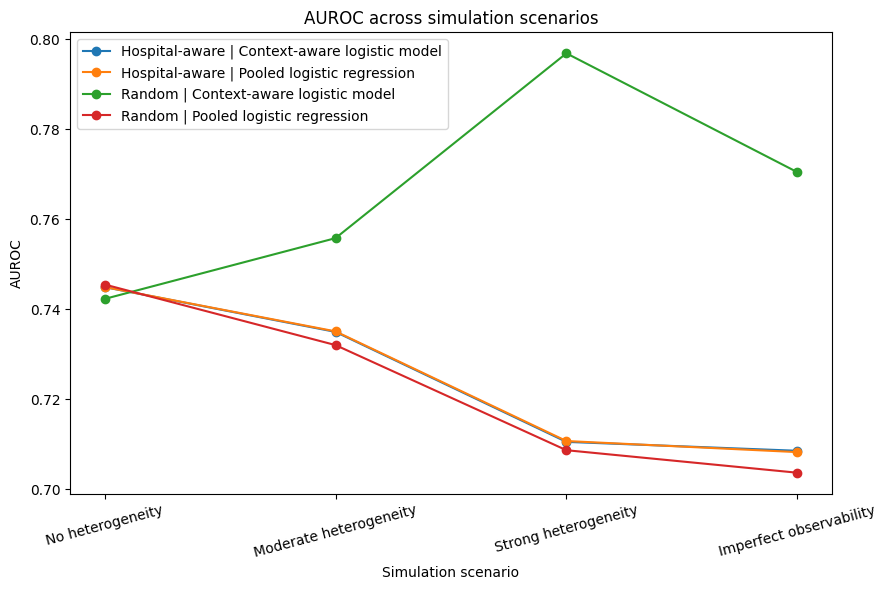

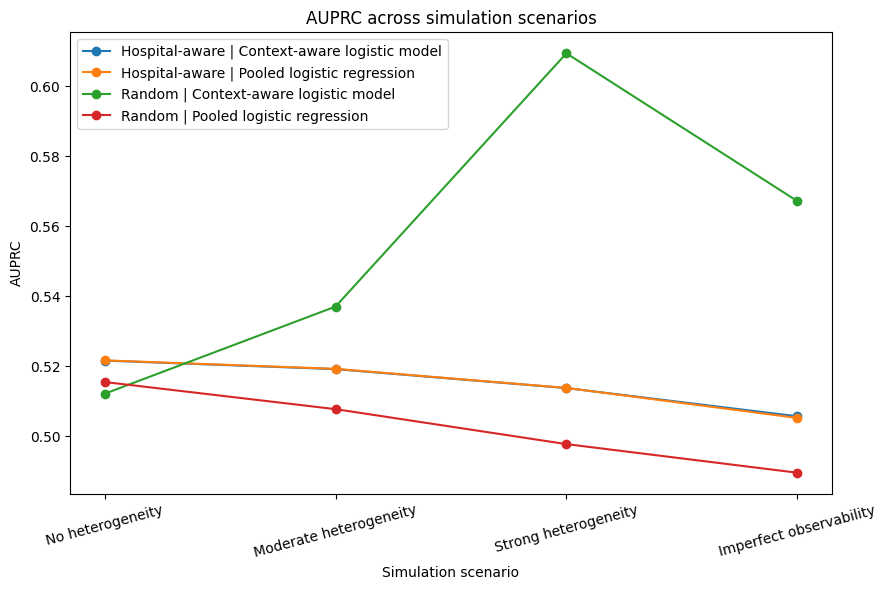

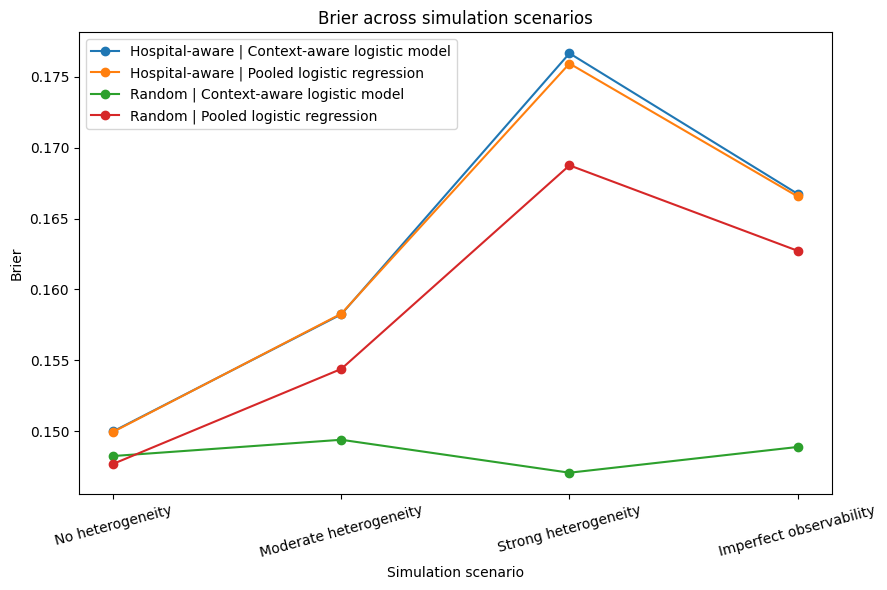

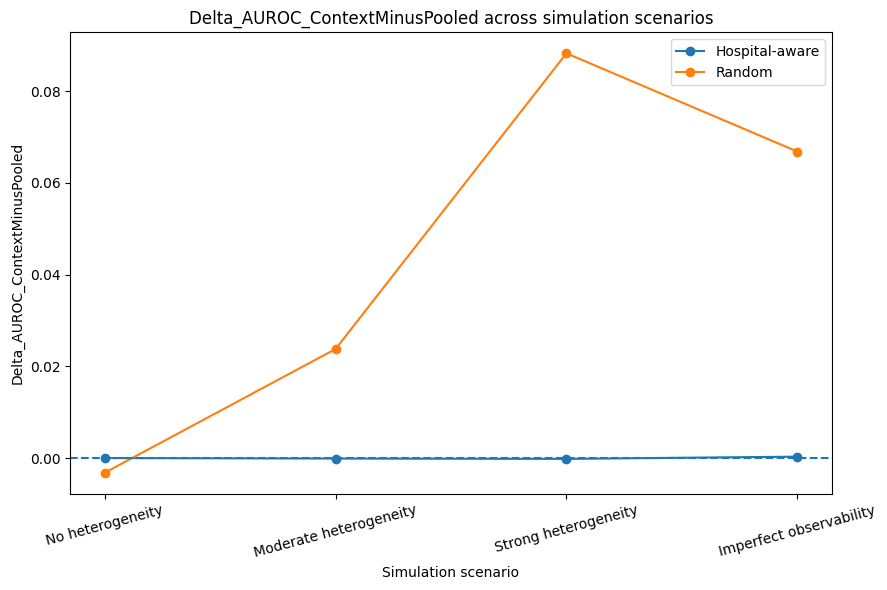

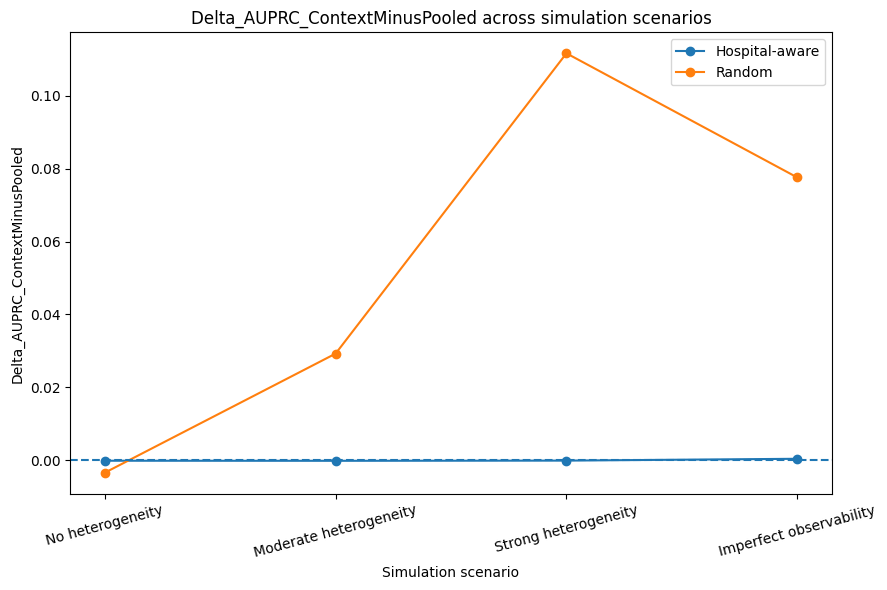

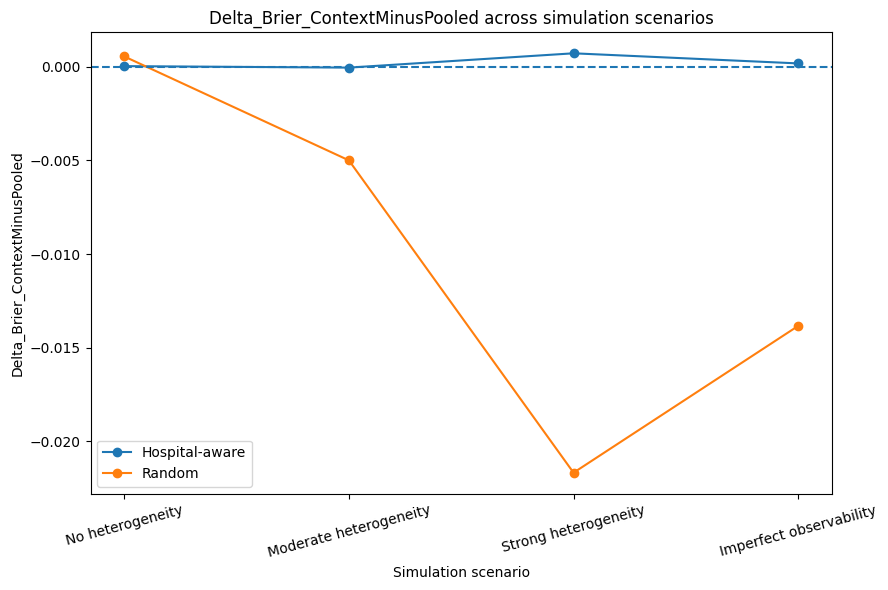

Done.


In [2]:
N_REPLICATIONS = 30
N_HOSPITALS = 40
OBS_PER_HOSPITAL = 300
SCENARIOS = {
    "No heterogeneity": {"sigma_u": 0.0, "zero_inflation": 0.0},
    "Moderate heterogeneity": {"sigma_u": 0.5, "zero_inflation": 0.0},
    "Strong heterogeneity": {"sigma_u": 1.0, "zero_inflation": 0.0},
    "Imperfect observability": {"sigma_u": 0.8, "zero_inflation": 0.35},
}
BETA = {"beta0": -1.4, "age": 0.20, "cm": 0.70, "dt": 0.30}
LOSS_SCENARIOS = {
    "Inspection-favored": {"lambda_K": 1.0, "lambda_I": 0.35, "c_I": 0.052, "c_R": 0.262},
    "Balanced": {"lambda_K": 1.0, "lambda_I": 0.35, "c_I": 0.078, "c_R": 0.183},
    "Replacement-favored": {"lambda_K": 1.0, "lambda_I": 0.35, "c_I": 0.052, "c_R": 0.145},
}
TARGET = "future_high_burden"
GROUP = "hospital_id"
FEATURES = ["age", "cm_burden", "dt_log1p"]

def generate_dataset(n_hospitals=N_HOSPITALS, obs_per_hospital=OBS_PER_HOSPITAL, sigma_u=0.5, zero_inflation=0.0, random_state=42):
    rng = np.random.default_rng(random_state)
    rows = []
    hospital_effects = rng.normal(0.0, sigma_u, size=n_hospitals)
    for h in range(n_hospitals):
        u_h = hospital_effects[h]
        age = np.clip(rng.gamma(shape=3.0, scale=3.0, size=obs_per_hospital) + rng.normal(0, 1.5), 0, None)
        cm = rng.poisson(np.clip(0.35 + 0.09 * age + rng.normal(0, 0.4), 0.02, None))
        downtime = rng.gamma(shape=1.5, scale=np.clip(1.0 + 0.35 * cm + rng.normal(0, 0.3), 0.2, None))
        if zero_inflation > 0:
            zc = rng.binomial(1, zero_inflation, size=obs_per_hospital).astype(bool)
            zd = rng.binomial(1, zero_inflation, size=obs_per_hospital).astype(bool)
            cm = cm.copy(); downtime = downtime.copy()
            cm[zc] = 0; downtime[zd] = 0.0
        rows.append(pd.DataFrame({"hospital_id": f"H{h:02d}", "age": age, "cm_burden": cm, "downtime_burden": downtime, "true_u_h": u_h}))
    df = pd.concat(rows, ignore_index=True)
    df["dt_log1p"] = np.log1p(df["downtime_burden"])
    df["age_s"] = (df["age"] - df["age"].mean()) / df["age"].std()
    df["cm_s"] = (df["cm_burden"] - df["cm_burden"].mean()) / (df["cm_burden"].std() + 1e-12)
    df["dt_s"] = (df["dt_log1p"] - df["dt_log1p"].mean()) / (df["dt_log1p"].std() + 1e-12)
    eta = BETA["beta0"] + BETA["age"]*df["age_s"].values + BETA["cm"]*df["cm_s"].values + BETA["dt"]*df["dt_s"].values + df["true_u_h"].values
    df["p_true"] = expit(eta)
    df[TARGET] = rng.binomial(1, df["p_true"].values)
    return df

def split_data(df, split_type, random_state):
    if split_type == "Random":
        train_idx, test_idx = train_test_split(np.arange(len(df)), test_size=0.25, stratify=df[TARGET], random_state=random_state)
    else:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
        train_idx, test_idx = next(gss.split(df, y=df[TARGET], groups=df[GROUP]))
    return df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

def fit_predict_pooled(train_df, test_df):
    model = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=5000))])
    model.fit(train_df[FEATURES], train_df[TARGET])
    return model.predict_proba(test_df[FEATURES])[:, 1]

def fit_predict_context(train_df, test_df):
    prep = ColumnTransformer([("num", StandardScaler(), FEATURES), ("hospital", OneHotEncoder(handle_unknown="ignore"), [GROUP])])
    model = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=5000))])
    model.fit(train_df[FEATURES + [GROUP]], train_df[TARGET])
    return model.predict_proba(test_df[FEATURES + [GROUP]])[:, 1]

def expected_loss_actions(p, params):
    lk = params["lambda_K"]*p
    li = params["c_I"] + params["lambda_I"]*p
    lr = np.full_like(p, params["c_R"], dtype=float)
    losses = np.vstack([lk, li, lr]).T
    idx = np.argmin(losses, axis=1)
    return idx, losses[np.arange(len(p)), idx]

def realized_loss(y, idx, params):
    out = np.zeros_like(y, dtype=float)
    out[idx == 0] = params["lambda_K"] * y[idx == 0]
    out[idx == 1] = params["c_I"] + params["lambda_I"] * y[idx == 1]
    out[idx == 2] = params["c_R"]
    return out

perf_rows, dec_rows = [], []
for scenario_name, sp in SCENARIOS.items():
    for rep in range(N_REPLICATIONS):
        df_sim = generate_dataset(sigma_u=sp["sigma_u"], zero_inflation=sp["zero_inflation"], random_state=10000+rep)
        for split_type in ["Random", "Hospital-aware"]:
            train_df, test_df = split_data(df_sim, split_type, 10000+rep)
            preds = {
                "Pooled logistic regression": fit_predict_pooled(train_df, test_df),
                "Context-aware logistic model": fit_predict_context(train_df, test_df)
            }
            y_test = test_df[TARGET].values
            for model_name, p in preds.items():
                perf_rows.append({
                    "Scenario": scenario_name, "Replication": rep, "Split": split_type, "Model": model_name,
                    "AUROC": roc_auc_score(y_test, p), "AUPRC": average_precision_score(y_test, p), "Brier": brier_score_loss(y_test, p)
                })
                for loss_name, lp in LOSS_SCENARIOS.items():
                    idx, el = expected_loss_actions(p, lp)
                    rl = realized_loss(y_test, idx, lp)
                    dec_rows.append({
                        "Scenario": scenario_name, "Replication": rep, "Split": split_type, "Model": model_name,
                        "Loss scenario": loss_name, "Avg. expected loss": el.mean(), "Avg. realized loss": rl.mean(),
                        "Keep rate": np.mean(idx == 0), "Inspect rate": np.mean(idx == 1), "Replace rate": np.mean(idx == 2),
                        "Positive rate among inspected": y_test[idx == 1].mean() if np.any(idx == 1) else np.nan,
                        "Positive rate among replaced": y_test[idx == 2].mean() if np.any(idx == 2) else np.nan,
                    })
perf_raw = pd.DataFrame(perf_rows)
decision_raw = pd.DataFrame(dec_rows)
perf_summary = perf_raw.groupby(["Scenario", "Split", "Model"]).agg(AUROC=("AUROC","mean"), AUPRC=("AUPRC","mean"), Brier=("Brier","mean")).reset_index()
decision_summary = decision_raw.groupby(["Scenario", "Split", "Model", "Loss scenario"]).agg(
    Avg_expected_loss=("Avg. expected loss","mean"), Avg_realized_loss=("Avg. realized loss","mean"),
    Keep_rate=("Keep rate","mean"), Inspect_rate=("Inspect rate","mean"), Replace_rate=("Replace rate","mean"),
    Positive_rate_among_inspected=("Positive rate among inspected","mean"),
    Positive_rate_among_replaced=("Positive rate among replaced","mean")
).reset_index()

wide = perf_raw.pivot_table(index=["Scenario", "Replication", "Split"], columns="Model", values=["AUROC","AUPRC","Brier"]).reset_index()
wide.columns = ["_".join([str(c) for c in col if c != ""]).strip("_") for col in wide.columns.values]
for metric in ["AUROC","AUPRC","Brier"]:
    wide[f"Delta_{metric}_ContextMinusPooled"] = wide[f"{metric}_Context-aware logistic model"] - wide[f"{metric}_Pooled logistic regression"]
leakage_table = wide.groupby(["Scenario","Split"])[["Delta_AUROC_ContextMinusPooled","Delta_AUPRC_ContextMinusPooled","Delta_Brier_ContextMinusPooled"]].mean().reset_index()

display(perf_summary); display(leakage_table)
perf_summary.to_csv(os.path.join(TAB_DIR, "table_simulation_performance.csv"), index=False)
with open(os.path.join(TAB_DIR, "table_simulation_performance.tex"), "w") as f:
    f.write(perf_summary.to_latex(index=False, float_format="%.3f"))
decision_summary.to_csv(os.path.join(TAB_DIR, "table_simulation_decision_summary.csv"), index=False)
with open(os.path.join(TAB_DIR, "table_simulation_decision_summary.tex"), "w") as f:
    f.write(decision_summary.to_latex(index=False, float_format="%.3f"))
leakage_table.to_csv(os.path.join(TAB_DIR, "table_contextual_leakage_contrast.csv"), index=False)
with open(os.path.join(TAB_DIR, "table_contextual_leakage_contrast.tex"), "w") as f:
    f.write(leakage_table.to_latex(index=False, float_format="%.3f"))

for metric, fname in [("AUROC","figure_simulation_auroc.png"), ("AUPRC","figure_simulation_auprc.png"), ("Brier","figure_simulation_brier.png")]:
    plt.figure(figsize=(9,6))
    for (split_type, model_name), g in perf_summary.groupby(["Split","Model"]):
        ordered = g.set_index("Scenario").reindex(list(SCENARIOS.keys())).reset_index()
        plt.plot(ordered["Scenario"], ordered[metric], marker="o", label=f"{split_type} | {model_name}")
    plt.xlabel("Simulation scenario"); plt.ylabel(metric); plt.title(f"{metric} across simulation scenarios")
    plt.xticks(rotation=15); plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=300)
    plt.show()

for metric, fname in [("Delta_AUROC_ContextMinusPooled","figure_contextual_leakage_delta_auroc.png"),
                      ("Delta_AUPRC_ContextMinusPooled","figure_contextual_leakage_delta_auprc.png"),
                      ("Delta_Brier_ContextMinusPooled","figure_contextual_leakage_delta_brier.png")]:
    plt.figure(figsize=(9,6))
    for split_type, g in leakage_table.groupby("Split"):
        ordered = g.set_index("Scenario").reindex(list(SCENARIOS.keys())).reset_index()
        plt.plot(ordered["Scenario"], ordered[metric], marker="o", label=split_type)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Simulation scenario"); plt.ylabel(metric); plt.title(f"{metric} across simulation scenarios")
    plt.xticks(rotation=15); plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=300)
    plt.show()
print("Done.")